In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Business_Operation_ml_ready.csv")
df.head()

,employee_id,experience_years,workload_percentage,active_tasks,performance_score,estimated_hours,hours_logged,progress_percentage,allocation_score,recommended_employee,...,required_skill_Django,required_skill_Excel,required_skill_Finance,required_skill_Machine Learning,required_skill_NLP,required_skill_Project Management,required_skill_Python,required_skill_React,required_skill_SQL,required_skill_Unknown
0,EMP2373,4.1,27.0,2,71.9,36.5,25.1,76.8,16.5,1,...,False,False,False,False,False,False,False,False,False,False
1,EMP4021,6.1,100.0,8,75.0,44.4,21.9,56.9,43.8,1,...,False,False,False,False,True,False,False,False,False,False
2,EMP2457,2.1,67.9,2,62.2,32.0,21.2,56.6,41.9,1,...,False,False,False,False,False,True,False,False,False,False
3,EMP2344,4.5,47.5,3,72.7,43.1,40.4,96.7,22.5,0,...,False,False,False,True,False,False,False,False,False,False
4,EMP205,13.6,49.3,2,77.0,33.5,29.4,92.8,49.2,1,...,False,False,True,False,False,False,False,False,False,False


In [3]:
print(df.shape)

(50000, 67)


In [4]:
print(df["recommended_employee"].value_counts())

recommended_employee
1    36354
0    13646
Name: count, dtype: int64


In [5]:
print(df["recommended_employee"].nunique())

2


In [6]:
X = df.drop(columns=["recommended_employee"])
y = df["recommended_employee"]

In [7]:
print(X.select_dtypes(include=["object"]).columns)

Index(['employee_id'], dtype='object')


In [8]:
X = X.drop(columns=["employee_id"])

In [9]:
print(X.select_dtypes(include=["object"]).columns)

Index([], dtype='object')


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
predictions = model.predict(X_test)

In [13]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.741


In [14]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.54      0.31      0.39      2729
           1       0.78      0.90      0.84      7271

    accuracy                           0.74     10000
   macro avg       0.66      0.61      0.61     10000
weighted avg       0.71      0.74      0.71     10000



In [15]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                          Feature  Importance
7                allocation_score    0.131803
4                 estimated_hours    0.071269
5                    hours_logged    0.070817
1             workload_percentage    0.066693
6             progress_percentage    0.061540
0                experience_years    0.058702
3               performance_score    0.058700
2                    active_tasks    0.036044
8                     skill_match    0.029379
38  availability_status_Available    0.027129


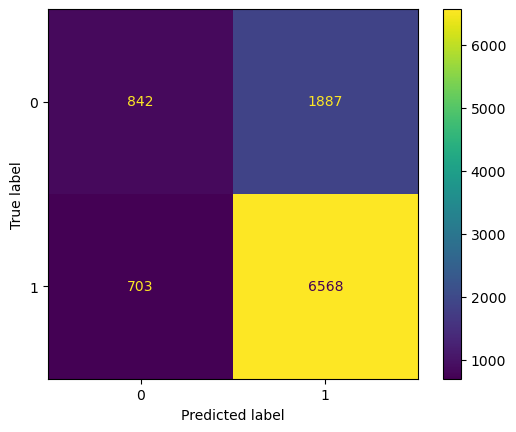

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions
)

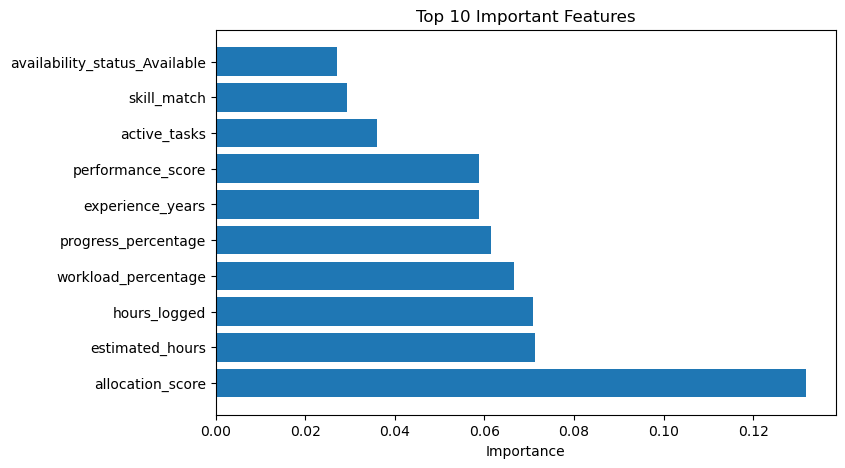

In [17]:
import matplotlib.pyplot as plt

top10 = importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10["Feature"], top10["Importance"])
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.show()

In [18]:
import joblib

joblib.dump(
    model,
    "employee_recommendation_model.pkl"
)

['employee_recommendation_model.pkl']